# Pandas Basics

## What is Pandas?

* Name derived from "panel data" or "python data analysis"
* Data exploration and analysis tool
* 2 main data structures:
  * `Series` - A 1-dimensional data structure (i.e. a column)
  * `DataFrame` - A 2-dimensional data structure (i.e. a table)

## Why Pandas?

* Speed: Number crunching is done by the Numpy library which performs arithmetic using native C code
* Power: SQL-like capabilities together with Python
* Visualizations: Integrate with libraries such as: Matplotlib, Bokeh, seaborn

## The standard Numpy and Pandas imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the data

Data is from the Origins Game Fair
* main site - https://www.originsgamefair.com/
* schedule - https://tabletop.events/conventions/origins-game-fair-2026/schedule
* scheule CSV - https://s3.amazonaws.com/conventionshare.tabletop.events/schedules/origins-game-fair-2026-schedule.csv

In [2]:
# read_csv has numerous options that let you dial in how 
# the data is loaded i.e. loading only certain columns, 
# specifying data types, specifying date/time format
df = pd.read_csv('origins-game-fair-2026-schedule.csv')

In [3]:
# Pandas can import data from a number of different formats
", ".join([s for s in dir(pd) if s.startswith('read_')])

'read_clipboard, read_csv, read_excel, read_feather, read_fwf, read_hdf, read_html, read_iceberg, read_json, read_orc, read_parquet, read_pickle, read_sas, read_spss, read_sql, read_sql_query, read_sql_table, read_stata, read_table, read_xml'

## Examine the Dataframe

### List Columns

In [4]:
df.columns

Index(['Event Name', 'Event Number', 'Event Type', 'Host Names', 'Description',
       'Price', 'Age Range', 'Max Tickets', 'Sold Count', 'Wait Count',
       'Starts', 'Start Date (UTC)', 'Duration (minutes)', 'More Info', 'Room',
       'Space', 'Date Created', 'Date Updated', 'View URI',
       'Conference Sessions', 'Trade Day Sessions', 'Game Master (GM)',
       'Game Edition', 'Game Publisher', 'Game Complexity',
       'Player Experience', 'Rules Taught', 'Is your event a tournament?',
       'What style of tournament', 'Tournament Stage/Round', 'Sub-Category',
       'Hosting Company, Group, or Club', 'Game System',
       'Will characters be provided?'],
      dtype='str')

### Column Data Types

In [5]:
df.dtypes[:5]  # Data types of first 5 columns

Event Name        str
Event Number    int64
Event Type        str
Host Names        str
Description       str
dtype: object

### df.info() - Column, Non-Null Count, and Datatypes

The output from `df.info()` is lengthy here is an excerpt.

```
<class 'pandas.DataFrame'>
RangeIndex: 8668 entries, 0 to 8667
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Event Name                       8668 non-null   str  
 1   Event Number                     8668 non-null   int64
 ...
 31  Hosting Company, Group, or Club  7804 non-null   str  
 32  Game System                      2953 non-null   str  
 33  Will characters be provided?     2463 non-null   str  
dtypes: int64(8), str(26)
memory usage: 2.2 MB
```

### Row Count

In [6]:
len(df)  # how many rows

8668

### Index

In [7]:
df.index

RangeIndex(start=0, stop=8668, step=1)

## Examine the Data 1

### Inspect values within field

In [8]:
df['Event Type'].value_counts()[:5]

Event Type
Board Game          3321
Roleplaying Game    2447
Miniatures Game      795
Card Game            594
Escape Games         343
Name: count, dtype: int64

### A simple pie chart

<Axes: >

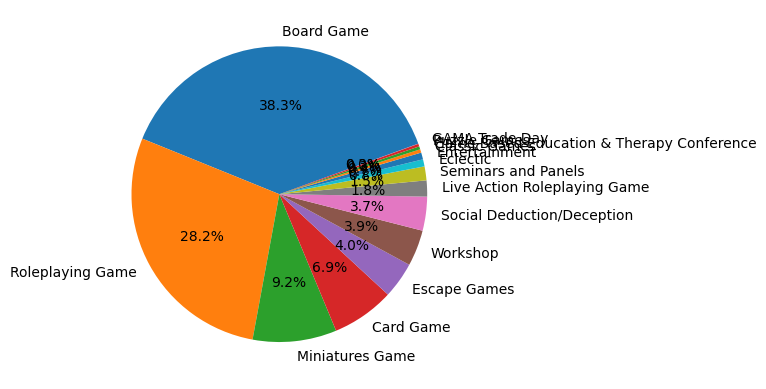

In [9]:
# A quick and dirty pie chart (uses the Matplot lib library)
df['Event Type'].value_counts().plot.pie(autopct='%1.1f%%', startangle=20)

### Narrow down to columns of interest

In [10]:
columns_of_interest = [
    'Event Name', 'Event Number', 'Event Type',
    'Description', 'Game System', 'Price', 'Age Range',
    'Max Tickets', 'Sold Count', 'Wait Count',
    'Start Date (UTC)', 'Duration (minutes)', 'Room',
    'Space', 'Rules Taught',
    'Will characters be provided?',
]

In [11]:
df[columns_of_interest]

,Event Name,Event Number,Event Type,Description,Game System,Price,Age Range,Max Tickets,Sold Count,Wait Count,Start Date (UTC),Duration (minutes),Room,Space,Rules Taught,Will characters be provided?
0,Retailer Summit at GAMA Trade Day,8065,GAMA Trade Day,The Retailer Summit is a full‑day gathering ex...,NaN,0,Adult (18+),150,85,0,2026-06-17T12:00:00,600,GCCC - 2nd Floor - Meeting A 216 - Edu Conference,Room,NaN,NaN
1,Creator Track at GAMA Trade Day,9052,GAMA Trade Day,Enjoy 4 Sessions specifically curated,NaN,0,Adult (18+),50,24,0,2026-06-17T12:00:00,600,GCCC - 2nd Floor - Meeting A 212 - Trade Day,Room,NaN,NaN
2,Arrival Push: A Game of Vectors Demo,8956,Board Game,All-new air traffic control board game with ev...,NaN,0,Teen Friendly (13+),6,6,0,2026-06-17T14:00:00,30,GCCC - Exhibit Hall Booth - #1020 - Pushing Ti...,Table 1,Yes,NaN
3,Neuroscape TCG Demo,9090,Card Game,Learn the New Cyberpunk themed collector card ...,NaN,0,Teen Friendly (13+),6,6,0,2026-06-17T14:00:00,120,Neuroscape TCG,Table 1,Yes,NaN
4,Arrival Push: A Game of Vectors Demo,8957,Board Game,All-new air traffic control board game with ev...,NaN,0,Teen Friendly (13+),6,4,0,2026-06-17T15:00:00,30,GCCC - Exhibit Hall Booth - #1020 - Pushing Ti...,Table 1,Yes,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8663,Two Rooms and a Boom,884,Social Deduction/Deception,Try the party game that's always a blast. Find...,NaN,0,All Ages (12 and under must be with an adult),30,27,0,2026-06-21T19:00:00,60,GCCC - 2nd Floor - Above Reg - Short North Bal...,Circle 1,Yes,NaN
8664,Weather Meeple,7123,Board Game,A multi-use card game where weather stations f...,NaN,0,Teen Friendly (13+),4,4,0,2026-06-21T19:00:00,60,GCCC - Hall C - #2518 - ProtoCLE,Table 09,Yes,NaN
8665,Pin Bazaar Pin Trading,8859,Workshop,Join Us for our Daily Pin Bazaar trading sessi...,NaN,0,All Ages (12 and under must be with an adult),200,2,0,2026-06-21T19:30:00,30,GCCC- Concourse - FoamBrain Pin Bazaar Trading...,Space,NaN,NaN
8666,Build A Foam Sword,1543,Workshop,We are back for yet another amazing year! Come...,NaN,15,All Ages (12 and under must be with an adult),20,0,0,2026-06-21T19:30:00,30,GCCC - 1st Floor - Meeting Room B 144 - Strong...,Room,NaN,NaN


### Get stats for some numeric fields

In [12]:
df[['Price', 'Max Tickets', 'Duration (minutes)']].describe()

,Price,Max Tickets,Duration (minutes)
count,8668.000000,8668.000000,8668.000000
mean,4.693470,14.121251,137.619982
std,11.381906,37.216541,79.974612
min,0.000000,0.000000,30.000000
25%,0.000000,5.000000,60.000000
50%,0.000000,6.000000,120.000000
75%,0.000000,10.000000,180.000000
max,243.000000,750.000000,600.000000


### Price histogram

In [13]:
def show_histogram(my_df, my_column, interval=10, title=None):
    my_series = my_df[my_column]
    my_stats = my_series.describe()
    my_min = int(my_stats['min'])
    my_max = int(my_stats['max'])
    my_series.hist(bins=(my_max - my_min) // interval)
    plt.title(
        title or f'Distribution of {my_column}s'
    )
    plt.xlabel(my_column)
    plt.ylabel('Frequency')
    plt.show()    

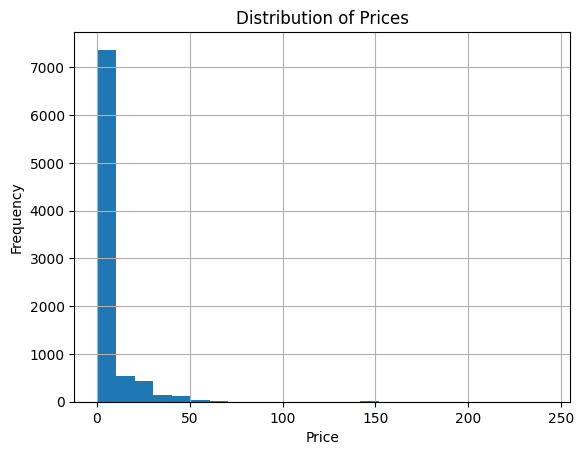

In [14]:
show_histogram(df, 'Price')

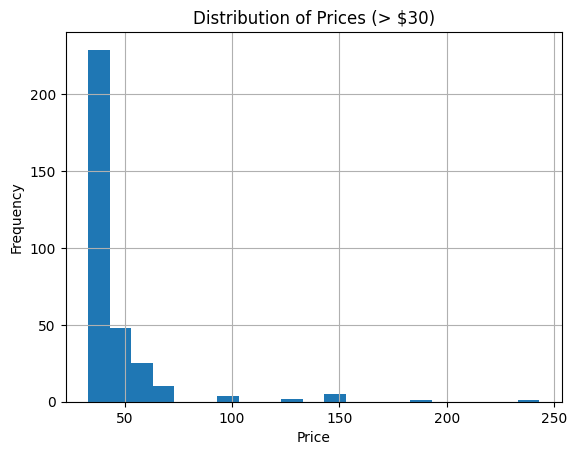

In [15]:
show_histogram(
    df[df['Price'] > 30],
    'Price',
    title="Distribution of Prices (> $30)"
)

## Dealing with Dates

We have 1 column containing a UTC datetime which was read as a string

In [16]:
START_DATE_UTC_FIELD = 'Start Date (UTC)'
df[START_DATE_UTC_FIELD].head(3)

0    2026-06-17T12:00:00
1    2026-06-17T12:00:00
2    2026-06-17T14:00:00
Name: Start Date (UTC), dtype: str

### Convert string to datetime place result in new column

In [17]:
# without the utc=True argument the datetime will be naive (lacking timezone)
df['start_date_utc'] = pd.to_datetime(df[START_DATE_UTC_FIELD], utc=True)
df['start_date_utc'].head(3)

0   2026-06-17 12:00:00+00:00
1   2026-06-17 12:00:00+00:00
2   2026-06-17 14:00:00+00:00
Name: start_date_utc, dtype: datetime64[us, UTC]

### Convert to local time

In [18]:
df['start_date'] = df['start_date_utc'].dt.tz_convert('America/New_York')
df['start_date'].head(3)

0   2026-06-17 08:00:00-04:00
1   2026-06-17 08:00:00-04:00
2   2026-06-17 10:00:00-04:00
Name: start_date, dtype: datetime64[us, America/New_York]

### View resulting "start date" columns.

In [19]:
df[[START_DATE_UTC_FIELD, 'start_date_utc', 'start_date']].head(5)

,Start Date (UTC),start_date_utc,start_date
0,2026-06-17T12:00:00,2026-06-17 12:00:00+00:00,2026-06-17 08:00:00-04:00
1,2026-06-17T12:00:00,2026-06-17 12:00:00+00:00,2026-06-17 08:00:00-04:00
2,2026-06-17T14:00:00,2026-06-17 14:00:00+00:00,2026-06-17 10:00:00-04:00
3,2026-06-17T14:00:00,2026-06-17 14:00:00+00:00,2026-06-17 10:00:00-04:00
4,2026-06-17T15:00:00,2026-06-17 15:00:00+00:00,2026-06-17 11:00:00-04:00


### .info for the "start date" columns

In [20]:
df[[START_DATE_UTC_FIELD, 'start_date_utc', 'start_date']].info()

<class 'pandas.DataFrame'>
RangeIndex: 8668 entries, 0 to 8667
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype                           
---  ------            --------------  -----                           
 0   Start Date (UTC)  8668 non-null   str                             
 1   start_date_utc    8668 non-null   datetime64[us, UTC]             
 2   start_date        8668 non-null   datetime64[us, America/New_York]
dtypes: datetime64[us, America/New_York](1), datetime64[us, UTC](1), str(1)
memory usage: 203.3 KB


### String -> datetime when reading csv

In [21]:
parsed_date_df = pd.read_csv(
    'origins-game-fair-2026-schedule.csv',
    usecols=[START_DATE_UTC_FIELD],
    parse_dates=[START_DATE_UTC_FIELD],
    date_format='%Y-%m-%dT%H:%M:%S',
)
parsed_date_df[START_DATE_UTC_FIELD].head(3)

0   2026-06-17 12:00:00
1   2026-06-17 12:00:00
2   2026-06-17 14:00:00
Name: Start Date (UTC), dtype: datetime64[us]

### Naive datetime to timezone aware

In [22]:
parsed_date_df['start_date_utc'] = parsed_date_df[START_DATE_UTC_FIELD].dt.tz_localize('UTC')
parsed_date_df['start_date_utc'].head(3)

0   2026-06-17 12:00:00+00:00
1   2026-06-17 12:00:00+00:00
2   2026-06-17 14:00:00+00:00
Name: start_date_utc, dtype: datetime64[us, UTC]

## Filtering

### Filter by Datetime

In [23]:
from datetime import datetime
from zoneinfo import ZoneInfo

nyc_timezone = ZoneInfo('America/New_York')
filter_start_date = datetime(2026, 6, 19, tzinfo=nyc_timezone)

# Events on Sunday the 22nd
filtered_df = df[df['start_date'] >= filter_start_date]
print(f"{len(filtered_df)=}")
filtered_df[['Event Name', 'start_date']].head(3)

len(filtered_df)=5496


,Event Name,start_date
3172,Are You a Werewolf / Ultimate Werewolf,2026-06-19 00:00:00-04:00
3173,Blood on the Clocktower: Trouble Brewing,2026-06-19 00:00:00-04:00
3174,For The Night Is Dark and Full of Terrors,2026-06-19 00:00:00-04:00


### Filter by Datetime Range and Other Criteria

In [24]:
from datetime import timedelta
filter_end_date = filter_start_date + timedelta(days=1)
date_mask = df['start_date'].between(
    filter_start_date,
    filter_end_date
)

filtered_df = df[date_mask]
print(f"{len(filtered_df)=}")
filtered_df[['Event Name', 'start_date']].head(3)

len(filtered_df)=2451


,Event Name,start_date
3172,Are You a Werewolf / Ultimate Werewolf,2026-06-19 00:00:00-04:00
3173,Blood on the Clocktower: Trouble Brewing,2026-06-19 00:00:00-04:00
3174,For The Night Is Dark and Full of Terrors,2026-06-19 00:00:00-04:00


### Filtering by multiple criteria

Use the `&` (bitwise AND), `|` (bitwise OR), and `!` NOT to build complex filters

In [25]:
filtered_df = df[
    date_mask &
    (df['Event Type'] == 'Roleplaying Game')
]
print(f"{len(filtered_df)=}")
filtered_df[['Event Name', 'Event Type', 'start_date']].sample(n=3)

len(filtered_df)=652


,Event Name,Event Type,start_date
5445,LNTE03: A Tear in the Velvet Lantern,Roleplaying Game,2026-06-19 20:00:00-04:00
3326,Ghost Registry,Roleplaying Game,2026-06-19 09:00:00-04:00
4391,Recruiting Crew: Roll a Pirate Borg Character,Roleplaying Game,2026-06-19 14:00:00-04:00


### Filtering for missing values

In [26]:
filtered_df = df[df['Game System'].isna()]
filtered_df[['Event Name', 'Event Type', 'Game System']].sample(5)

,Event Name,Event Type,Game System
2115,Dungeons & Dragons: Builders of Baldur's Gate ...,Miniatures Game,NaN
2148,The Seekers,Board Game,NaN
7535,Madoshi: Priests of the Sun and Moon,Board Game,NaN
6920,Wizard Miners,Card Game,NaN
7096,Ultimate Werewolf: Extreme Edition,Social Deduction/Deception,NaN


### Filtering for values that AREN'T missing

In [27]:
filtered_df = df[df['Game System'].notna()]
filtered_df[['Event Name', 'Event Type', 'Game System']].sample(5)

,Event Name,Event Type,Game System
1368,Ruin of the Witch Kings,Roleplaying Game,Mazes Fantasy Roleplaying
2840,"Everyday Heroes, Learn to Play: Out of Gas",Roleplaying Game,Everyday Heroes
2575,Army Ants,Roleplaying Game,Shadowdark
7947,Amtgard 101,Live Action Roleplaying Game,Amtgard v8
7678,Legends of Greyhawk - At the Epicenter,Roleplaying Game,Dungeons and Dragons


## Practical Example - Compare popularity of Event Types between the 2 years

### Function to load csv files

In [28]:
def load_csv(filename: str) -> pd.DataFrame:
    return pd.read_csv(
        filename,
        usecols=['Event Type', 'Max Tickets', 'Sold Count', 'Wait Count', START_DATE_UTC_FIELD],
        parse_dates=[START_DATE_UTC_FIELD],
        date_format='%Y-%m-%dT%H:%M:%S',
    )

### Load 2025 data

In [29]:
origins2025_df = load_csv('origins-game-fair-2025-schedule.csv')
origins2025_df.head(3)

,Event Type,Max Tickets,Sold Count,Wait Count,Start Date (UTC)
0,Seminars and Panels,250,152,0,2025-06-18 12:00:00
1,Board Game,5,5,2,2025-06-18 16:00:00
2,Live Action Roleplaying Game,4,0,0,2025-06-18 16:00:00


### Load 2026 data

In [30]:
origins2026_df = load_csv('origins-game-fair-2026-schedule.csv')
origins2026_df.head(3)

,Event Type,Max Tickets,Sold Count,Wait Count,Start Date (UTC)
0,GAMA Trade Day,150,85,0,2026-06-17 12:00:00
1,GAMA Trade Day,50,24,0,2026-06-17 12:00:00
2,Board Game,6,6,0,2026-06-17 14:00:00


### Concatenate the DataFrames together

In [31]:
merged_df = pd.concat([origins2025_df, origins2026_df])
merged_df.sample(5)

,Event Type,Max Tickets,Sold Count,Wait Count,Start Date (UTC)
6574,Miniatures Game,6,6,5,2026-06-20 17:00:00
4280,Card Game,4,2,0,2025-06-20 19:30:00
2082,Roleplaying Game,5,5,0,2025-06-19 19:00:00
215,Board Game,18,18,0,2026-06-17 18:00:00
2784,Roleplaying Game,12,0,0,2026-06-18 23:00:00


In [32]:
merged_df[START_DATE_UTC_FIELD].dt.year

0       2025
1       2025
2       2025
3       2025
4       2025
        ... 
8663    2026
8664    2026
8665    2026
8666    2026
8667    2026
Name: Start Date (UTC), Length: 16483, dtype: int32

### Check row counts to see results of pd.concat()

In [33]:
labels_and_dfs = [('2025', origins2025_df), ('2026', origins2026_df), ('merged', merged_df)]
for label, df in labels_and_dfs:
    print(f"{label:<8}  {len(df):8,}")

2025         7,815
2026         8,668
merged      16,483


### Compute sold_ratio

In [34]:
merged_df = merged_df[merged_df['Max Tickets'] > 0]
merged_df['sold_ratio'] = (merged_df['Sold Count'] + merged_df['Wait Count']) / merged_df['Max Tickets']
merged_df['year'] = merged_df[START_DATE_UTC_FIELD].dt.year
merged_df.head(5)

,Event Type,Max Tickets,Sold Count,Wait Count,Start Date (UTC),sold_ratio,year
0,Seminars and Panels,250,152,0,2025-06-18 12:00:00,0.608,2025
1,Board Game,5,5,2,2025-06-18 16:00:00,1.400,2025
2,Live Action Roleplaying Game,4,0,0,2025-06-18 16:00:00,0.000,2025
3,Roleplaying Game,6,6,0,2025-06-18 16:00:00,1.000,2025
4,Board Game,6,6,0,2025-06-18 16:00:00,1.000,2025


In [35]:
merged_df = merged_df.set_index(['year', 'Event Type'], append=True)
merged_df.head(5)

,,,Max Tickets,Sold Count,Wait Count,Start Date (UTC),sold_ratio
,year,Event Type,,,,,
0,2025,Seminars and Panels,250,152,0,2025-06-18 12:00:00,0.608
1,2025,Board Game,5,5,2,2025-06-18 16:00:00,1.400
2,2025,Live Action Roleplaying Game,4,0,0,2025-06-18 16:00:00,0.000
3,2025,Roleplaying Game,6,6,0,2025-06-18 16:00:00,1.000
4,2025,Board Game,6,6,0,2025-06-18 16:00:00,1.000


In [38]:
sold_ratios_by_year_and_event = merged_df.groupby(level=['year', 'Event Type'])['sold_ratio'].mean()
sold_ratios_by_year_and_event

year  Event Type                               
2025  Board Game                                   0.983612
      Card Game                                    0.539698
      Classic Games                                0.450347
      Eclectic                                     0.868011
      Entertainment                                0.564000
      Live Action Roleplaying Game                 0.178589
      Media Only                                   0.111111
      Miniatures Game                              0.753545
      Puzzle Games                                 0.370117
      Roleplaying Game                             1.043859
      Seminars and Panels                          0.433831
      Social Deduction/Deception                   0.714814
      Workshop                                     0.442564
2026  Board Game                                   0.989260
      Card Game                                    0.599694
      Classic Games                                1

In [40]:
type(sold_ratios_by_year_and_event)

pandas.Series

In [44]:
sold_ratios_by_year_and_event[2025]

Event Type
Board Game                      0.983612
Card Game                       0.539698
Classic Games                   0.450347
Eclectic                        0.868011
Entertainment                   0.564000
Live Action Roleplaying Game    0.178589
Media Only                      0.111111
Miniatures Game                 0.753545
Puzzle Games                    0.370117
Roleplaying Game                1.043859
Seminars and Panels             0.433831
Social Deduction/Deception      0.714814
Workshop                        0.442564
Name: sold_ratio, dtype: float64

In [45]:
sold_ratios_by_year_and_event[2026]

Event Type
Board Game                                   0.989260
Card Game                                    0.599694
Classic Games                                1.210938
Eclectic                                     0.751116
Entertainment                                0.154107
Escape Games                                 0.099211
GAMA Trade Day                               0.523333
Game-Based Education & Therapy Conference    0.559103
Live Action Roleplaying Game                 0.191365
Miniatures Game                              0.647489
Puzzle Games                                 1.137375
Roleplaying Game                             0.850521
Seminars and Panels                          0.248055
Social Deduction/Deception                   0.519066
Workshop                                     0.269154
Name: sold_ratio, dtype: float64

<Axes: xlabel='year,Event Type'>

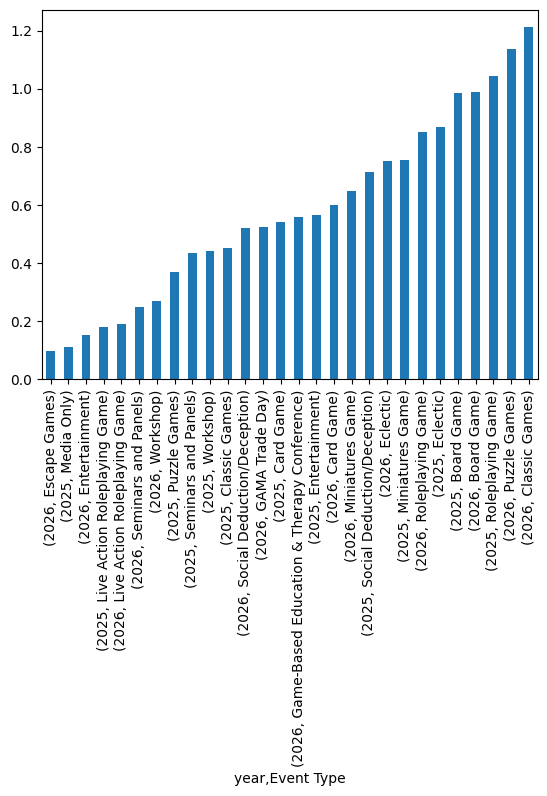

In [37]:
sold_rations_by_year_and_event.sort_values().plot.bar()

In [58]:
origins2025_df[
    (origins2025_df['Event Type'] == 'Miniatures Game') &
    (origins2025_df['Sold Count'] < 1)
]

,Event Type,Max Tickets,Sold Count,Wait Count,sold_ratio
907,Miniatures Game,4,0,0,0.0
1133,Miniatures Game,24,0,0,0.0
1170,Miniatures Game,24,0,0,0.0
1257,Miniatures Game,4,0,0,0.0
1317,Miniatures Game,10,0,0,0.0
...,...,...,...,...,...
6983,Miniatures Game,10,0,0,0.0
7272,Miniatures Game,8,0,0,0.0
7353,Miniatures Game,8,0,0,0.0
7608,Miniatures Game,4,0,0,0.0


In [42]:
origins2025_df.sample(5)

,Event Type,Max Tickets,Sold Count,Wait Count
5376,Board Game,4,4,1
945,Roleplaying Game,6,6,2
1678,Seminars and Panels,30,11,0
7531,Board Game,6,6,0
3348,Roleplaying Game,6,3,0


In [ ]:
columns_of_interest = ['Event Type', 'Max Tickets', 'Sold Count', 'Wait Count']

In [37]:
origins2025_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7815 entries, 0 to 7814
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Event Name                       7815 non-null   str           
 1   Event Number                     7815 non-null   int64         
 2   Event Type                       7815 non-null   str           
 3   Host Names                       7815 non-null   str           
 4   Description                      7814 non-null   str           
 5   Price                            7815 non-null   int64         
 6   Age Range                        7815 non-null   str           
 7   Max Tickets                      7815 non-null   int64         
 8   Sold Count                       7815 non-null   int64         
 9   Wait Count                       7815 non-null   int64         
 10  Starts                           7815 non-null   str           
 11  St

## Resources

* https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html